<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

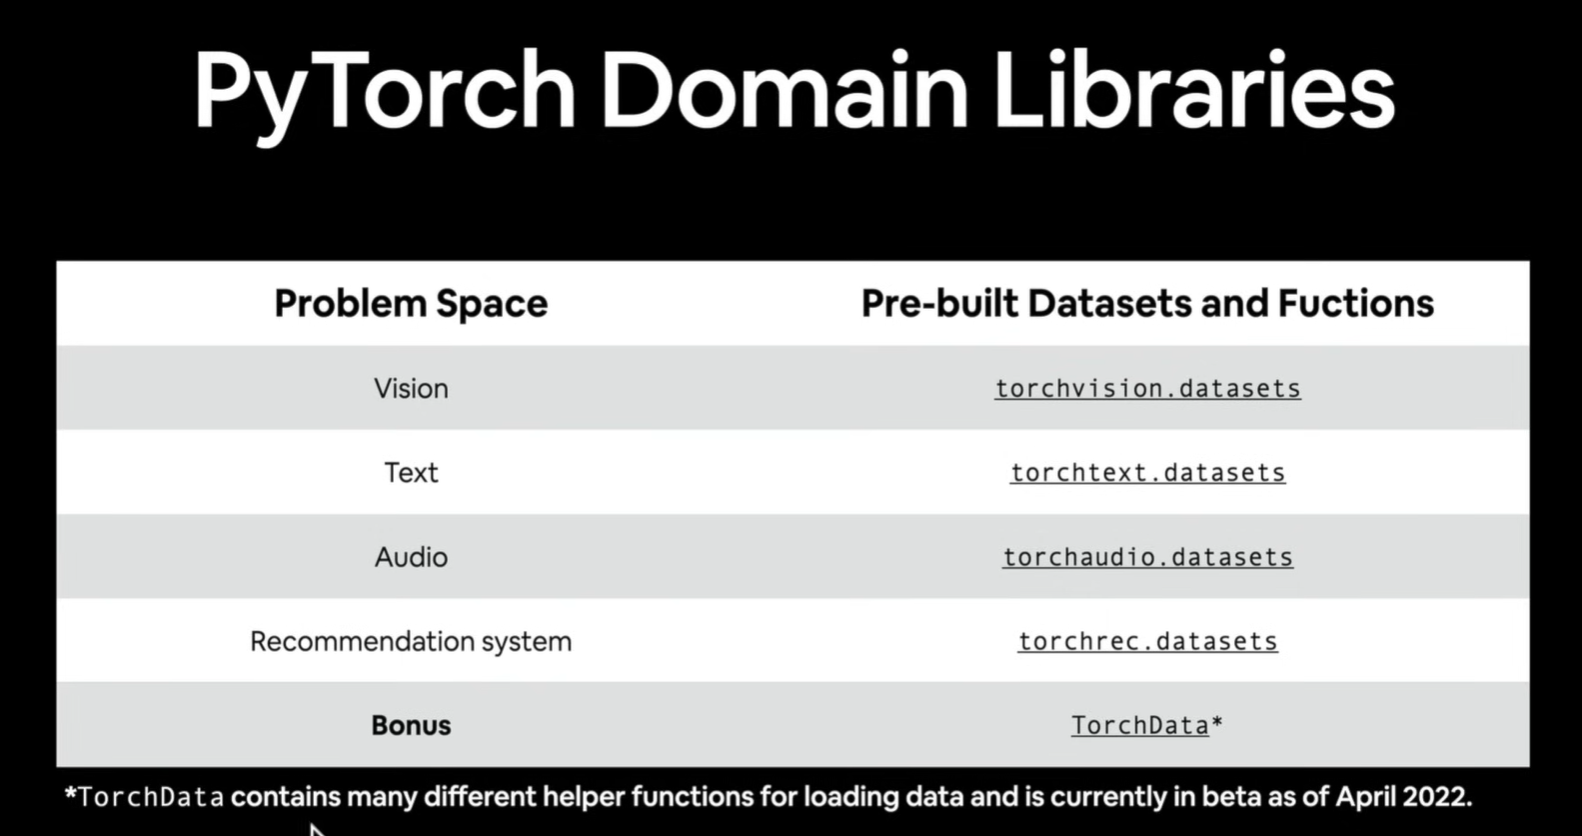

#4 Pytorch custom datsets
* How do you get your own data in to pytorch
* ONe of the method of using it is via : Custom datasets


### Domain Libraries:
* Depending on thxt audio vicdeo, we would want to look for pytorch domain libraries for existing data loading functions and customizable data loading function


In [121]:
import torch
from torch import nn
import pandas as pd
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [122]:
##Get Data
import requests
import zipfile
from pathlib import Path

#setting up a path to the datafolder,
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

print(f"creating {image_path} directory as it DNE")
image_path.mkdir(parents=True, exist_ok=True)

#Downloading the




creating data/pizza_steak_sushi directory as it DNE


In [123]:
import requests
import zipfile
from pathlib import Path




with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza steak sushi data")
    f.write(request.content)
#unzip the data

with zipfile.ZipFile (data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza steak and sushi data...")
  zip_ref.extractall(image_path)

Unzipping pizza steak and sushi data...


##2 Becoming one with the data



In [124]:
import os

def walk_through_dir(dir_path):
  """ Walks throgh the path returning its contents
  """
  for dirpath , dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


In [125]:
walk_through_dir(image_path)
#

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [126]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [127]:
##use the pillow and sleep LOL, use the
image_path

PosixPath('data/pizza_steak_sushi')

In [128]:
#watching the images
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/sushi/748830.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2574453.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1129338.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3737197.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/821108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/169392.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/840444.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1571146.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2797464.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/773725.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2021685.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2323548.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2590819.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2019344.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/14046.jpg'),
 PosixPath('dat

data/pizza_steak_sushi/train/sushi/377047.jpg
sushi
height 512, width 382


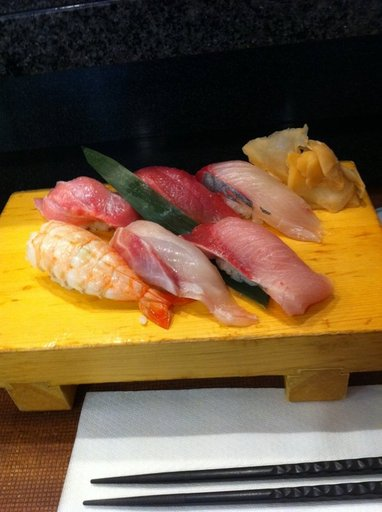

In [129]:
#pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)
image_class = random_image_path.parent.stem
print(image_class)
img = Image.open(random_image_path)
print(f"height {img.height}, width {img.width}")
img

Text(0.5, 1.0, 'Image Class :sushi | image shape : (512, 382, 3)')

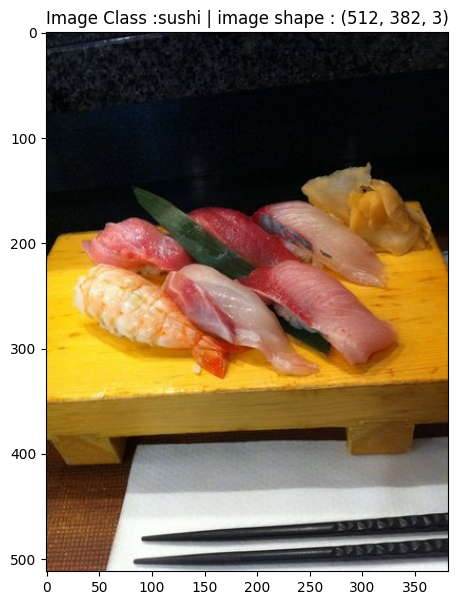

In [130]:
import matplotlib.pyplot as plt
import numpy as np # Keep numpy import if other parts of the notebook rely on it, otherwise not strictly needed here if just calling imshow

# The 'img' variable is already a torch.Tensor as expected by the imshow helper.
# We will use the 'imshow' helper function defined in cell NJQJeIWIa3jm to properly display the image.
img_as_array = np.asarray(img)

img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))

plt.imshow(img_as_array)
plt.title(f"Image Class :{image_class} | image shape : {img_as_array.shape}")

array([[[ 22,  25,  32],
        [ 20,  23,  30],
        [ 17,  20,  27],
        ...,
        [ 12,  15,  20],
        [  9,  12,  17],
        [  5,   8,  13]],

       [[ 20,  23,  30],
        [ 21,  24,  31],
        [ 21,  24,  31],
        ...,
        [ 13,  16,  21],
        [ 10,  13,  18],
        [  6,   9,  14]],

       [[ 14,  17,  24],
        [ 16,  19,  26],
        [ 18,  21,  28],
        ...,
        [ 14,  17,  22],
        [ 12,  15,  20],
        [  9,  12,  17]],

       ...,

       [[133,  78,  57],
        [139,  84,  63],
        [143,  88,  67],
        ...,
        [245, 246, 248],
        [244, 245, 247],
        [244, 245, 247]],

       [[131,  76,  55],
        [144,  89,  68],
        [143,  88,  67],
        ...,
        [245, 245, 245],
        [243, 243, 243],
        [242, 242, 242]],

       [[119,  64,  43],
        [142,  87,  66],
        [134,  79,  58],
        ...,
        [248, 248, 248],
        [245, 245, 245],
        [243, 243, 243]]], dtype=uint8)
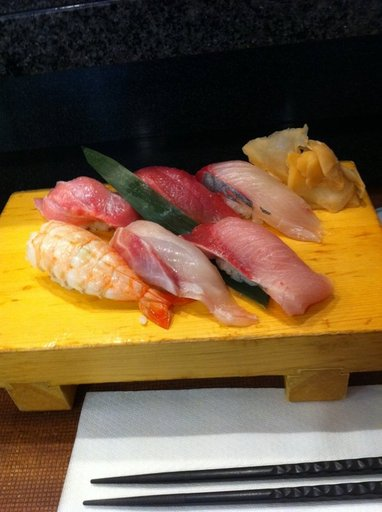

In [131]:
img_as_array

#Image from the custom datasets in to tensor

* Before we can use our image data with pytoch
  * Turn the target data in to tensors
  * Turn it into a torch.utils.data.Dataset
  * Turn it into torch.utils.data.dataloader
  

In [132]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    #Resize our images to 64, 64
    transforms.Resize(size = (64 ,64)),
    #flip the images randomly in horizontal axis
    transforms.RandomHorizontalFlip(p=0.5),
    #transform it into torch tensor
    transforms.ToTensor()
])




In [133]:
print(data_transform(img).shape,
data_transform(img).dtype)



torch.Size([3, 64, 64]) torch.float32


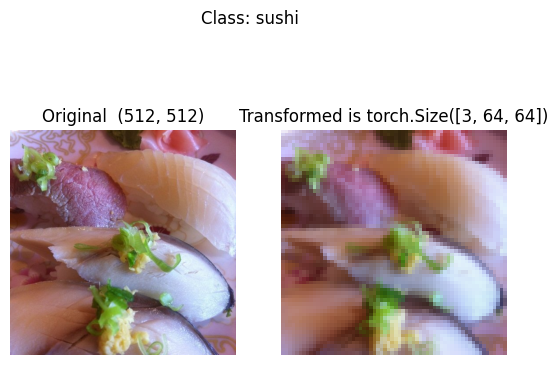

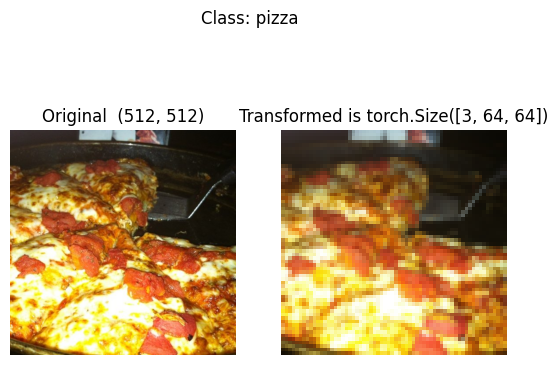

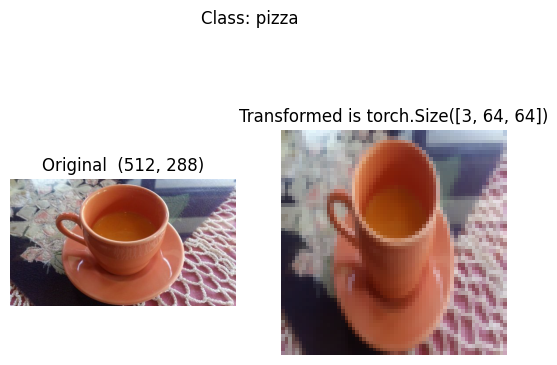

In [134]:
def plot_transformed_images(image_paths: list, transform, n =3, seed = None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image in random_image_paths:
    with Image.open(image) as f:
      fig,ax = plt.subplots(nrows = 1, ncols =2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original  {f.size}")
      ax[0].axis(False)

      transformed_images = transform(f)
      ax[1].imshow(transformed_images.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
      ax[1].set_title(f"Transformed is {transformed_images.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image.parent.stem}")

plot_transformed_images(image_paths = image_path_list, transform = data_transform, n =3, seed = None)

In [135]:
#loading image data using image folder

from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform, # a transform for the data
                                  target_transform = None) #a tramsform for the label/target

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform,
                                 target_transform = None)



In [136]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [137]:
import os

# List the contents of the train_dir to show how class names are derived
print(f'Contents of {train_dir}:')
for item in os.listdir(train_dir):
    print(item)

Contents of data/pizza_steak_sushi/train:
sushi
pizza
steak


As you can see, the subdirectories `pizza`, `steak`, and `sushi` within the `train_dir` are automatically used as the class names by `datasets.ImageFolder`.

In [138]:
#check the length of our datasets

len(train_data) , len(test_data)


(225, 75)

In [139]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [140]:
img, label = train_data[0][0], train_data[0][1]
img
print(f"Image tensor \n{img}")
print(f"Image shape : {img.shape}")
print(f"Image datatyp: {img.dtype}")
print(f"Image label : {label} ({class_names[label]})")

Image tensor 
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [141]:
class_names[label]

'pizza'

Original shape is given by torch.Size([3, 64, 64])
New shape when we permute it is torch.Size([64, 64, 3])


Text(0.5, 1.0, 'Class : pizza')

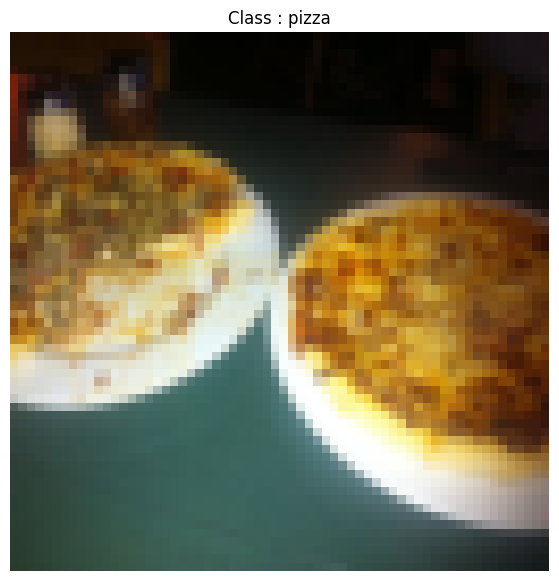

In [142]:
import matplotlib.pyplot as plt

img_transpose = img.permute(1,2,0)

print(f"Original shape is given by {img.shape}")
print(f"New shape when we permute it is {img_transpose.shape}")

plt.figure(figsize=(10,7))
plt.imshow(img_transpose)
plt.axis("off")# we can also set it to false
plt.title(f"Class : {class_names[label]}")

In [143]:
# turning datasets into dataloader
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset = train_data,
                               batch_size = 32,
                               shuffle = True,
                               )
test_data_loader = DataLoader(dataset = test_data,
                              batch_size = 32,
                              shuffle = False,
                              )


In [144]:
import os
os.cpu_count()

2

In [145]:
len(train_data), len(test_data)

(225, 75)

In [146]:
len(train_data_loader), len(test_data_loader)

(8, 3)

In [147]:
img, label = next(iter(train_data_loader))

In [148]:
img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

#replicating the function of imagefolder by replicating our own image class
#Option 2, loading image data with a custom data set

1. WAnt to be able to load images from file
2. Want to be able to get class name from the dataset
3. Want to be able to het classes as dictionary from the data set


Pros:
* We can create a custom dataset out of almosr anything
* Not limited to pytthon pre build `Dataset` functions

Cons:
* Even though you could create Dataset out of almost anything, it doesn't mean it will work
* We have to write more code, it could be prone to errors and also it could have performance issue



In [149]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

#instance of torchvision.datasets.ImageFolder replicate this function
print(f" Just like we have it here {train_data.classes}, {train_data.class_to_idx}")


#Mission
#1 Want to be able load images from file
#2 Want to be able to get class names from the dataset
#3 Want to be able to get classes as dicrionary from the dataset

#strategy
# Get the class names using os.scandir() to traverse a target directory traditionally it will be in te standar image classification format
# Raise an error if the class names are not foung( if this happens there might be somthing wrong with the structure
# Turn the vclass names int o a dict and a list and return them


 Just like we have it here ['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2}


In [150]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """
  Finds the class folder names in a target directory,
  """

  #get the c;ass names by scanning in the target directory
  target_directory = directory
  print(f"Target directory is {train_dir}")

  #Gert the c;lass na,es from the target of the directory
  class_names_found = sorted([entry.name for entry in  os.scandir(target_directory) if entry.is_dir() ])

  #2 raise an error if class name could not be found
  if not class_names_found:
    raise FileNotFoundError(f"Could not find any classes in {target_directory}... please check file structure")

  else: class_to_idx = {class_name: i for i, class_name in enumerate(class_names_found)}

  #3 Create a dictionary of imndex label




  return class_names_found , class_to_idx


In [151]:
find_classes(train_dir)

Target directory is data/pizza_steak_sushi/train


(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# create a custom dataset to replicate ImageFolfer
1. Sub class `torch.utils.data.Dataset`
2. Inherite our sublass with a target directorty (duirectory where we want to get our data dfrom) as well as trabsfirn if we would like to transform our data/
3. Create several attributes:
  * paths paths of our image_class
  * transform the transform we would like to %set_env
  * classes a list of target classes
  * class_to_idc - a dict of the target classes
4. We want tp create a function to `load images`, this function will open the images
5. Overwrite the len method to ge the length of the dataset
6. Overwrite the get item method to return a given sample when passed an index





In [152]:
# write a custom dataset class

from torch.utils.data import Dataset

class CustomDataset(Dataset):
  #Initializing our custom dataset
  def __init__(self, target_dir: str, transform = None):
    #getting all the images within the images fdirecory
    self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg")) # the first * represents all the folder/files, the second one " *.jpg " represents all the files with the extension of .jpg at the end
    #setup transfrom
    self.transform = transform

    #Create classes and class to idx attribute, we have created a functino for that we can use those function
    self.classes, self.class_to_idx = find_classes(target_dir)

  #Create a function to load image (this should be a class method, not nested)
  def load_image(self, index:int):
    #We are going to use the pillow class from the python library
    """
    Opens the imae via path and returns it, must use index as an attribute to get the image  when calling this function
    """
    image_path = self.paths[index]
    return Image.open(image_path)

  #Over writing the len method, this will simply return how many samples we have in our datasets
  def __len__(self):
    """
    Returns the total number of sample
    """
    return len(self.paths)

  #If we are using the subclass of the dataset we have to use the get item function, so we are overriding it

  def __getitem__(self, index: int)-> Tuple[torch.Tensor, int]: # basically will return image and the label, where image is a tensor and label is here as an integer
    """
    returns one sample of fata and label (X,y)
    this expects the path in format: data_folder/class_name/   image.jpg
    """
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    #If transform is necessary, passing the image to that transform
    if self.transform:
      return self.transform(img), class_idx # Return both transformed image and label
    else:
      return img, class_idx # If no transform, return original PIL image and label


In [153]:
from torchvision import transforms
test_transforms = transforms.Compose([transforms.Resize(size = (64,64)),
                                      transforms.RandomHorizontalFlip(p= 0.5),
                                      transforms.ToTensor])
train_transforms = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.ToTensor()
])

In [154]:

train_data_custom = CustomDataset(target_dir= train_dir, transform = train_transforms)
test_data_custom = CustomDataset(target_dir= test_dir, transform = test_transforms)

train_data_custom, test_data_custom

Target directory is data/pizza_steak_sushi/train
Target directory is data/pizza_steak_sushi/train


(<__main__.CustomDataset at 0x7bd72436a240>,
 <__main__.CustomDataset at 0x7bd724280920>)

In [155]:
len(train_data), len(train_data_custom)

(225, 225)

In [156]:
len(test_data), len(test_data_custom)

(75, 75)

In [157]:
 train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [158]:
#check for equality netween two datasets
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data.classes)

True
True


In [159]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes:List[str]= None,
                          n:int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  if n > 10:
    n= 10
    display_shape = False
    print(f"For display purpose n should not be larger than 10")

  if seed:
    random.seed(seed)

  #get random sample indexes
  random_sample_idx = random.sample(range(len(dataset)), k = n)

#setup plot
  plt.figure(figsize=(16,8))



  #loop through ranndom indexes and plot them through matplot lib
  for i, target_sample in enumerate(random_sample_idx):
    targ_image, targ_label = dataset[target_sample][0], dataset[target_sample][1]

  #adjust tensor dimension to match matplotlib com[patblity
    targ_image_adjust = targ_image.permute(1,2,0)

    #pllt adjusted sample
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape:{targ_image_adjust.shape}"
        plt.title(title)

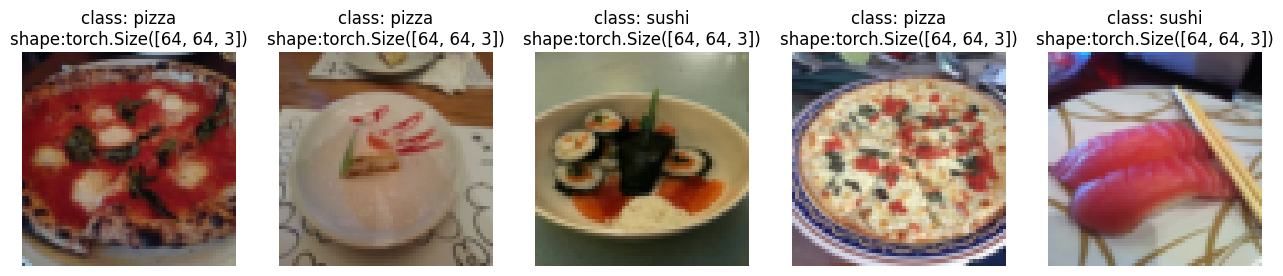

In [160]:
display_random_images(train_data,
                      n =5,
                      classes = class_names,
                      seed = None)

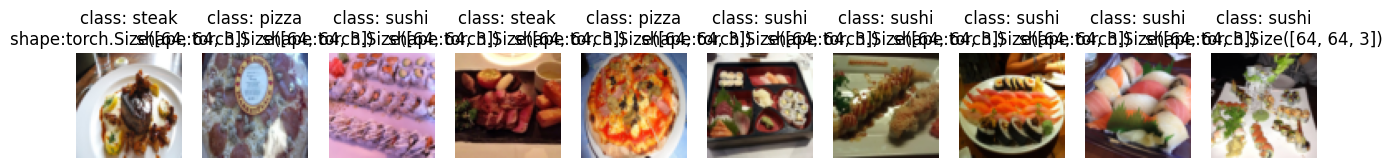

In [161]:
display_random_images(train_data_custom,
                      n =10,
                      classes = class_names,
                      seed =None)

In [162]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader_custom = DataLoader(
    dataset = train_data_custom,
    batch_size = BATCH_SIZE,
    num_workers=1,
    shuffle = True,
)
test_dataloader_custom = DataLoader(
    dataset = test_data_custom,
    batch_size = BATCH_SIZE,
    num_workers = 1,
    shuffle = False,
)



In [163]:
print(f"{train_dataloader_custom},{ test_dataloader_custom}\n")

img_custom, label_custom = next(iter(train_dataloader_custom))


print(img_custom.shape, label_custom.shape)

<torch.utils.data.dataloader.DataLoader object at 0x7bd72346f2c0>,<torch.utils.data.dataloader.DataLoader object at 0x7bd72413dd60>

torch.Size([32, 3, 64, 64]) torch.Size([32])


Feature,ResNet,DenseNet
Connection Type,Addition (+),Concatenation (Combine)
Memory Usage,Lower (Faster training),Higher (More memory intensive)
Parameter Efficiency,Good,Excellent (Does more with less)
Best For,"distinct objects (Cars, Cats)","Subtle textures (X-rays, Tumors)"

In [164]:
train_transform = transforms.Compose([transforms.Resize(size= (224,224)),
                                       transforms.TrivialAugmentWide(num_magnitude_bins=30),
                                       transforms.ToTensor()])

rest_transform= transforms.Compose([transforms.Resize(size= (224,224)),
                                       transforms.ToTensor()])

image_path_list = list(image_path.glob("*/*/*.jpg"))

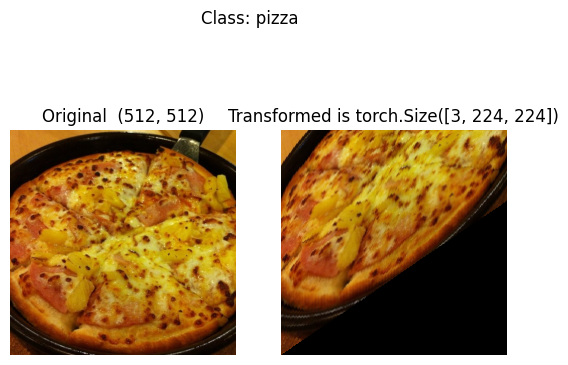

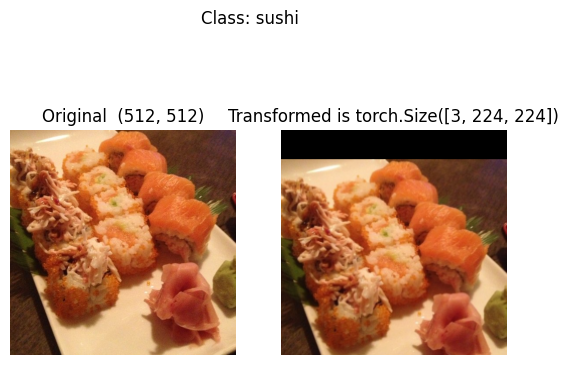

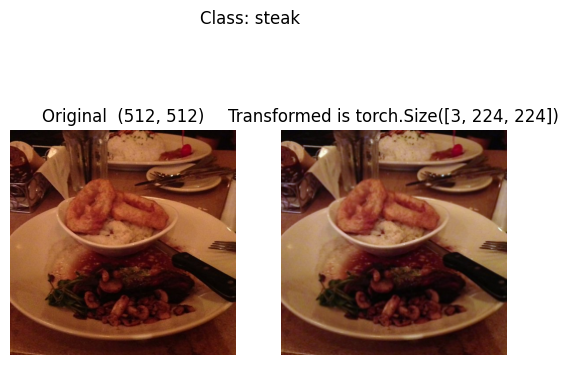

In [165]:
plot_transformed_images(
    image_paths=image_path_list,
    transform = train_transform,
    n=3,
    seed = None)



In [166]:
#CREATE THE SIMPLE TRANSFORM
simple_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                      transforms.ToTensor])

#Load and transform Data

from torchvision import datasets
train_data_simple = datasets.ImageFolder(root = train_dir,
                                         transform = simple_transform)
test_data_simple = datasets.ImageFolder(root = test_dir,
                                         transform = simple_transform)


In [167]:
#2 tr=urn ther datasets intyo dataloadser
import os
BATCHSIZE = 32
from torch.utils.data import dataloader

train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                   batch_size = BATCHSIZE,
                                     shuffle = True,
                                     num_workers = os.cpu_count())
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                     batch_size = BATCHSIZE,
                                     shuffle = False,
                                     num_workers = os.cpu_count())



In [168]:
class TinyVGG(nn.Module):
  """
  Model architechture copying tiny vgg from CNN explaineer
  """
  def __init__ (self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.convBlock1 = nn.Sequential(
              nn.Conv2d(in_channels = input_shape,
                        out_channels = hidden_units,
                        kernel_size = 3,
                        stride = 1,
                        padding = 0),
              nn.ReLU(),
              nn.Conv2d(in_channels = hidden_units,
                        out_channels = hidden_units,
                        kernel_size = 3,
                        stride = 1,
                        padding = 0),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2,
                            stride = 2)
      )
    self.convBlock2= nn.Sequential(
                        nn.Conv2d
                          (
                          in_channels = hidden_units,
                          out_channels = hidden_units,
                          kernel_size = 3,
                          stride =1,
                          padding =0
                          ),
                        nn.ReLU(),
                        nn.Conv2d
                          (in_channels = hidden_units,
                                  out_channels = hidden_units,
                                  kernel_size = 3,
                                  stride =1,
                                  padding = 0
                          ),
                        nn.MaxPool2d(kernel_size = 2,
                                      stride = 2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features= hidden_units*13*13,
                out_features = output_shape)
  )

  def forward(self,x):
      x= self.convBlock1(x)
      # print(x.shape)
      x = self.convBlock2(x)
      # print(x.shape)
      x = self.classifier(x)
      # print(x.shape)
      return x



In [169]:


image_batch, label_batch = next(iter(train_dataloader_custom))
image_batch.shape, label_batch.shape


(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [170]:

torch.manual_seed(42)

model_0 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(class_names)).to(device)

In [171]:
model_0(image_batch)

tensor([[ 0.0249, -0.0212,  0.0235],
        [ 0.0262, -0.0217,  0.0285],
        [ 0.0225, -0.0159,  0.0267],
        [ 0.0232, -0.0189,  0.0256],
        [ 0.0241, -0.0212,  0.0258],
        [ 0.0237, -0.0171,  0.0292],
        [ 0.0298, -0.0211,  0.0323],
        [ 0.0251, -0.0173,  0.0242],
        [ 0.0247, -0.0245,  0.0235],
        [ 0.0257, -0.0162,  0.0282],
        [ 0.0270, -0.0185,  0.0335],
        [ 0.0272, -0.0240,  0.0235],
        [ 0.0248, -0.0162,  0.0271],
        [ 0.0246, -0.0139,  0.0254],
        [ 0.0267, -0.0227,  0.0278],
        [ 0.0289, -0.0101,  0.0328],
        [ 0.0259, -0.0203,  0.0266],
        [ 0.0253, -0.0245,  0.0344],
        [ 0.0220, -0.0222,  0.0257],
        [ 0.0280, -0.0141,  0.0284],
        [ 0.0282, -0.0150,  0.0282],
        [ 0.0251, -0.0158,  0.0277],
        [ 0.0232, -0.0228,  0.0202],
        [ 0.0234, -0.0192,  0.0273],
        [ 0.0245, -0.0221,  0.0223],
        [ 0.0257, -0.0178,  0.0252],
        [ 0.0301, -0.0173,  0.0313],
 

In [172]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [173]:
from torchinfo import summary
summary(model_0, input_size = [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─MaxPool2d: 2-9                    [1, 10, 13, 13]           --
├─Sequential: 1-3                        [1, 3]                    --
│    └─Flat

## Making trainign and testing steps which will be compatibele for any kind of the model on the dataloader

* train_step() - takes in a model and dataloader and trains the model on the dataloader
* `test_step` takes in a model and dataloader and evalusates the model on the data loader



In [174]:

def traim_step(model: torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  model.train()

  train_loss, test_acc = 0, 0

  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)

    #Do the forward pass
    y_pred = model(X) #This outputs model logits

    #Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    #Optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #Optimizer step
    optimizer.step()

    #calculate the accuracy
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)


  train_loss = train_loss / len(dataloader)
  train_acc = train_acc/len(dataloader)
  return train_loss, train_acc







In [178]:
def test_step(model: torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
    with torch.inference_mode():
            model.eval()
            test_loss, test_acc = 0,0

            for batch, (X,y) in enumerate(dataloader):
              X,y = X.to(device), y.to(device)

              #Do the forward pass
              test_preds_logits = model(X)
              loss = loss_fn(test_preds_logits, y)
              test_loss += loss.item()


              #For the accuracy
              test_pred_labels = test_preds_logits.argmax(dim=1)
              test_acc +=((test_pred_labels == y).sum().item()/len(test_pred_labels))


            test_loss = test_loss / len(dataloader)
            test_acc = test_acc / len(dataloader)
            return test_loss, test_acc

In [ ]:
def train_function(Epochs: int, train_step, test_step, model, train_dataloader, test_dataloader, optimizer, loss_fn, device):
